In [18]:
import numpy as np  
import sys
print(sys.executable)

/home/jack/miniconda3/envs/aa276_hw1/bin/python


In [19]:
# import jax
# import jax.numpy as jnp
# import numpy as np
# from IPython.display import HTML
# import matplotlib.animation as anim
# import matplotlib.pyplot as plt
# import plotly.graph_objects as go

# import hj_reachability as hj
########################################################
import jax
import jax.numpy as jnp
import numpy as np
import hj_reachability as hj

from hj_reachability import dynamics
from hj_reachability import sets
from tqdm import tqdm

In [ ]:
# class InvertedPendulum(hj.ControlAndDisturbanceAffineDynamics):
#     def __init__(
#         self,
#         m=2.0,
#         l=1.0,
#         g=10.0,
#         u_max=3.0,
#         d_min=0.0,
#         d_max=0.4,
#         control_mode="max",
#         disturbance_mode="min"
#     ):
#         self.m = m
#         self.l = l
#         self.g = g

#         control_space = hj.sets.Box(
#             jnp.array([-u_max]),
#             jnp.array([ u_max])
#         )

#         disturbance_space = hj.sets.Box(
#             jnp.array([d_min]),
#             jnp.array([d_max])
#         )

#         super().__init__(
#             control_mode=control_mode,
#             disturbance_mode=disturbance_mode,
#             control_space=control_space,
#             disturbance_space=disturbance_space,
#         )

#     def open_loop_dynamics(self, state, time):
#         theta, omega = state

#         return jnp.array([
#             omega,
#             (self.g / self.l) * jnp.sin(theta)
#         ])

#     def control_jacobian(self, state, time):
#         return jnp.array([
#             [0.0],
#             [1.0 / (self.m * self.l**2)]
#         ])

#     def disturbance_jacobian(self, state, time):
#         return jnp.array([
#             [1.0],   # d enters theta_dot
#             [0.0]
#         ])

# class InvertedPendulum(hj.ControlAndDisturbanceAffineDynamics):
#     def __init__(
#         self,
#         m=2.0,
#         l=1.0,
#         g=10.0,
#         u_max=3.0,
#         control_mode="max",      
#         disturbance_mode="min"
#     ):
#         self.m = m
#         self.l = l
#         self.g = g

#         control_space = hj.sets.Box(
#             jnp.array([-u_max]),
#             jnp.array([ u_max])
#         )

#         # No disturbance in my model.
#         disturbance_space = hj.sets.Box(
#             jnp.array([0.0]),
#             jnp.array([0.0])
#         )

#         super().__init__(
#             control_mode=control_mode,
#             disturbance_mode=disturbance_mode,
#             control_space=control_space,
#             disturbance_space=disturbance_space,
#         )

#     def open_loop_dynamics(self, state, time):
#         theta, omega = state
#         return jnp.array([
#             omega,
#             (self.g / self.l) * jnp.sin(theta)
#         ])

#     def control_jacobian(self, state, time):
#         return jnp.array([
#             [0.0],
#             [1.0 / (self.m * self.l**2)]
#         ])

#     def disturbance_jacobian(self, state, time):
#         return jnp.array([
#             [0.0],
#             [0.0]
#         ])




class InvertedPendulum(dynamics.ControlAndDisturbanceAffineDynamics):

  def __init__(self,
               m=2.0,
               l=1.0,
               g=10.0,
               u_max=3.0,
               d_min=0.0,
               d_max=0.4):
    self.m = m
    self.l = l
    self.g = g

    # Controller chooses torque u in [-3, 3].
    # For a backward reachable tube of the failure set, use control_mode='max'
    # to compute the best-case controlled safety value.
    control_mode = "max"
    disturbance_mode = "min"

    control_space = sets.Box(
        jnp.array([-u_max]),
        jnp.array([+u_max])
    )

    # No disturbance in this problem.
    disturbance_space = sets.Box(
        jnp.array([d_min]),
        jnp.array([d_max])
    )
    

    super().__init__(
        control_mode,
        disturbance_mode,
        control_space,
        disturbance_space
    )

  def open_loop_dynamics(self, state, time):
    theta, theta_dot = state

    return jnp.array([
        theta_dot,
        (self.g / self.l) * jnp.sin(theta)
    ])

  def control_jacobian(self, state, time):
    return jnp.array([
        [0.0],
        [1.0 / (self.m * self.l ** 2)]
    ])

  def disturbance_jacobian(self, state, time):
    return jnp.array([
        [1.0],
        [0.0]
    ])

In [46]:
# dynamics = InvertedPendulum(
#     m=2.0,
#     l=1.0,
#     g=10.0,
#     u_max=3.0,
#     control_mode="max"  
# )

# grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
#     hj.sets.Box(
#         lo=np.array([-np.pi, -10.0]),
#         hi=np.array([ np.pi,  10.0])
#     ),
#     (101, 101),
#     periodic_dims=0   # theta is periodic
# )

# values = 0.3 - jnp.abs(grid.states[..., 0])

# solver_settings = hj.SolverSettings.with_accuracy("very_high", hamiltonian_postprocessor=hj.solver.backwards_reachable_tube)

grid = hj.Grid.from_lattice_parameters_and_boundary_conditions(
    hj.sets.Box(
        np.array([-np.pi, -10.0]),
        np.array([+np.pi, +10.0])
    ),
    (101, 101)
)

values = 0.3 - jnp.abs(grid.states[..., 0])
# failure_values = jnp.abs(grid.states[..., 0]) - 0.3

solver_settings = hj.SolverSettings.with_accuracy("very_high", hamiltonian_postprocessor=hj.solver.backwards_reachable_tube)

In [47]:
# times = np.linspace(0, -5, 101)
# initial_values = values
# all_values = hj.solve(solver_settings, dynamics, grid, times, initial_values)

times = np.linspace(0, -5, 101)

# Problem parameters
m = 2.0       # kg
l = 1.0       # m
g = 10.0      # m / s^2
u_max = 3.0   # torque bound

pendulum_dynamics = InvertedPendulum(m=m, l=l, g=g, u_max=u_max)

all_values = hj.solve(solver_settings, pendulum_dynamics, grid, times, values)

100%|##########|  5.0000/5.0 [00:05<00:00,  1.06s/sim_s]


In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# ------------------------------------------------------------
# Parameters
# ------------------------------------------------------------
m = 2.0
l = 1.0
g = 10.0

u_min = -3.0
u_max = 3.0

d_min = 0.0
d_max = 0.4

In [49]:
#Helpers  

def wrap_theta(theta):
    return (theta + np.pi) % (2 * np.pi) - np.pi


def pendulum_dynamics_disturbed(x, u, d):

    theta, omega = x

    return np.array([
        omega + d,
        (g / l) * np.sin(theta) + u / (m * l**2)
    ])


def u_nominal(x, t):

    theta, omega = x

    if 0.0 <= t < 1.0:
        u = 3.0
    elif 1.0 <= t < 2.0:
        u = -3.0
    elif 2.0 <= t < 3.0:
        u = 3.0
    else:
        u = m * l**2 * (
            -(g / l) * np.sin(theta)
            - 1.5 * theta
            - 1.5 * omega
        )
    return np.clip(u, u_min, u_max)

In [50]:
# V values and DV
V_star = np.array(all_values[-1])

grads_star = grid.grad_values(V_star, solver_settings.upwind_scheme)
grads_star = np.array(grads_star)

# beta2 = dV / d omega
beta2s = grads_star[:, :, 1]

theta_vec = np.array(grid.coordinate_vectors[0])
omega_vec = np.array(grid.coordinate_vectors[1])

V_interpolator = RegularGridInterpolator(
    (theta_vec, omega_vec),
    V_star,
    bounds_error=False,
    fill_value=None
)

beta2_interpolator = RegularGridInterpolator(
    (theta_vec, omega_vec),
    beta2s,
    bounds_error=False,
    fill_value=None
)

def value_function(x):

    theta, omega = x
    x_query = np.array([wrap_theta(theta), omega])
    return V_interpolator(x_query).item()

def optimal_safety_controller(x):

    theta, omega = x
    x_query = np.array([wrap_theta(theta), omega])
    
    beta2 = beta2_interpolator(x_query).item()
    
    if beta2 > 0:
        return u_max
    elif beta2 < 0:
        return u_min
    else:
        return 0.0
    
def least_restrictive_filter(x, t):

    Vx = value_function(x)

    if Vx > 0.0:
        return u_nominal(x, t)
    else:
        return optimal_safety_controller(x)

In [ ]:

def is_safe_trajectory(xs):
    theta_traj = xs[:, 0]
    return not np.any(np.abs(theta_traj) >= 0.3)



def simulate_disturbed_least_restrictive(
    x0=np.array([0.05, 0.05]),
    T=5.0,
    dt=0.01,
    rng=None
):
    if rng is None:
        rng = np.random.default_rng()

    nt = int(round(T / dt)) + 1
    ts = np.linspace(0.0, T, nt)

    xs = np.zeros((nt, 2))
    us_lr = np.zeros(nt - 1)
    us_nom = np.zeros(nt - 1)
    ds = np.zeros(nt - 1)
    Vs = np.zeros(nt)

    xs[0] = np.array(x0, dtype=float)
    xs[0, 0] = wrap_theta(xs[0, 0])

    Vs[0] = value_function(xs[0])

    for k in range(nt - 1):
        t = ts[k]
        x = xs[k]

        # Draw disturbance d ~ Uniform(0, 0.4)
        d = rng.uniform(d_min, d_max)
        # print("state:", x)
        # print("disturbance:", d)
        u_nom = u_nominal(x, t)
        u_lr = least_restrictive_filter(x, t)

        us_nom[k] = u_nom
        us_lr[k] = u_lr
        ds[k] = d

        # Euler integration with disturbed dynamics
        # print("next state:", x + dt * pendulum_dynamics_disturbed(x, u_lr, d))
        xs[k + 1] = x + dt * pendulum_dynamics_disturbed(x, u_lr, d)
        xs[k + 1, 0] = wrap_theta(xs[k + 1, 0])

        Vs[k + 1] = value_function(xs[k + 1])

    # safe = is_safe_trajectory(xs, value_function)
    safe = is_safe_trajectory(xs)

    return ts, xs, us_lr, us_nom, ds, Vs, safe



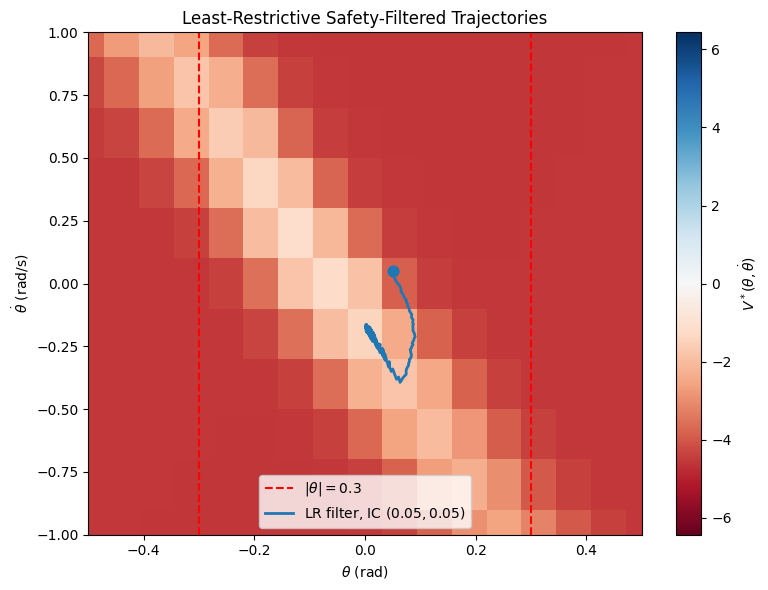

In [52]:
# draw one disturbed simulation out
ts2, xs2, us2_lr, us2_nom, ds, Vs2, safe = simulate_disturbed_least_restrictive(np.array([0.05, 0.05]), T=5.0, dt=0.01)

plt.figure(figsize=(8, 6))

vbar = np.max(np.abs(V_star))

plt.pcolormesh(
    theta_vec,
    omega_vec,
    V_star.T,
    shading="auto",
    cmap="RdBu",
    vmin=-vbar,
    vmax=+vbar
)
plt.colorbar(label=r"$V^*(\theta,\dot{\theta})$")

plt.contour(
    theta_vec,
    omega_vec,
    V_star.T,
    levels=[0],
    colors="k",
    linewidths=2
)

# Failure set boundary: |theta| = 0.3
plt.axvline(-0.3, color="r", linestyle="--", linewidth=1.5, label=r"$|\theta|=0.3$")
plt.axvline(0.3, color="r", linestyle="--", linewidth=1.5)

plt.plot(xs2[:, 0], xs2[:, 1], linewidth=2, label=r"LR filter, IC $(0.05,0.05)$")


plt.scatter(xs2[0, 0], xs2[0, 1], marker="o", s=60)

plt.xlabel(r"$\theta$ (rad)")
plt.ylabel(r"$\dot{\theta}$ (rad/s)")
plt.title("Least-Restrictive Safety-Filtered Trajectories")
plt.xlim([-0.5, 0.5])
plt.ylim([-1.0, 1.0])
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
# ------------------------------------------------------------
# 100 rollouts simulation
# ------------------------------------------------------------

num_sims = 100
x0 = np.array([0.05, 0.05])
T = 5.0
dt = 0.01

rng = np.random.default_rng(0)

all_xs = []
all_us_lr = []
all_us_nom = []
all_ds = []
all_Vs = []
safe_flags = []

for i in range(num_sims):
    ts, xs, us_lr, us_nom, ds, Vs, safe = simulate_disturbed_least_restrictive(
        x0=x0,
        T=T,
        dt=dt,
        rng=rng
    )

    all_xs.append(xs)
    all_us_lr.append(us_lr)
    all_us_nom.append(us_nom)
    all_ds.append(ds)
    all_Vs.append(Vs)
    safe_flags.append(safe)

safe_flags = np.array(safe_flags)

num_safe = np.sum(safe_flags)
safety_rate = num_safe / num_sims

print(f"Number of safe simulations: {num_safe} / {num_sims}")
print(f"Safety rate: {100 * safety_rate:.2f}%")

max_abs_thetas = np.array([
    np.max(np.abs(xs[:, 0])) for xs in all_xs
])

print(f"Largest |theta| over all simulations: {np.max(max_abs_thetas):.4f}")
print(f"Smallest safety margin: {0.3 - np.max(max_abs_thetas):.4f}")
print(f"Mean max |theta|: {np.mean(max_abs_thetas):.4f}")

Number of safe simulations: 100 / 100
Safety rate: 100.00%
Largest |theta| over all simulations: 0.1183
Smallest safety margin: 0.1817
Mean max |theta|: 0.0931
